# 📊 End-to-End ML Pipeline: Customer Churn Prediction
### Using scikit-learn `Pipeline` API, `GridSearchCV`, and `joblib`

**Objective:** Build a reusable, production-ready machine learning pipeline that predicts telecom customer churn.

**Dataset:** [Telco Customer Churn Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM sample dataset)

**Pipeline covers:**
1. Data loading & exploration
2. Preprocessing (scaling numeric features, encoding categorical features) via `ColumnTransformer`
3. Model training — Logistic Regression & Random Forest — wrapped in a single `Pipeline`
4. Hyperparameter tuning with `GridSearchCV`
5. Model evaluation
6. Exporting the complete fitted pipeline with `joblib` for reuse in production


## 1. Setup — Install & Import Libraries

In [1]:
# Install required packages (Colab usually has most of these pre-installed)
!pip install -q scikit-learn pandas numpy joblib matplotlib seaborn


In [2]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)


## 2. Load the Dataset

We use the well-known IBM Telco Customer Churn dataset (7,043 customers, 21 columns), hosted as a public CSV.
If the URL ever changes, you can instead upload the CSV manually in Colab via the file browser and update `DATA_PATH`.


In [3]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

try:
    df = pd.read_csv(DATA_URL)
    print("Loaded dataset from URL.")
except Exception as e:
    print("Could not fetch from URL, please upload the CSV manually.")
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    df = pd.read_csv(fname)

print(df.shape)
df.head()


Loaded dataset from URL.
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Quick Exploratory Data Analysis

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# TotalCharges is sometimes read as object due to blank strings -> convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# customerID is just an identifier, drop it
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column:
TotalCharges    11
dtype: int64


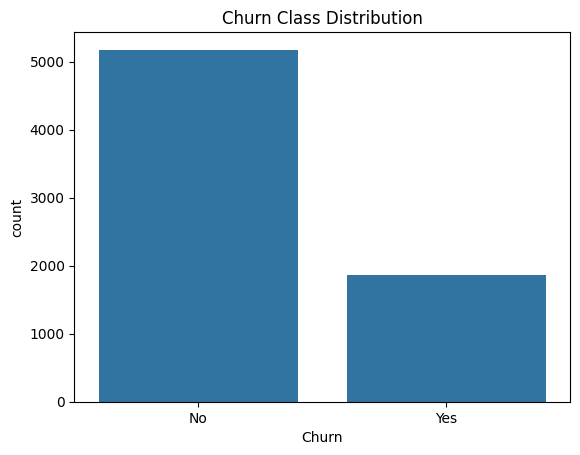

,proportion
Churn,
No,0.73463
Yes,0.26537


In [6]:
# Target distribution
sns.countplot(data=df, x="Churn")
plt.title("Churn Class Distribution")
plt.show()

df["Churn"].value_counts(normalize=True)


## 4. Prepare Features & Target

In [7]:
# Encode target: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
y = df["Churn"]

# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5634, 19)
Test shape: (1409, 19)


## 6. Build Preprocessing Pipeline

We use `ColumnTransformer` to apply:
- `SimpleImputer` + `StandardScaler` on numeric columns
- `SimpleImputer` + `OneHotEncoder` on categorical columns

This preprocessing step will be embedded inside the final `Pipeline`, so the exact same
transformations are guaranteed to be applied at training and inference time.


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


## 7. Full Model Pipeline

We define a single end-to-end `Pipeline` with two steps:
1. `preprocessor` — all data cleaning/encoding/scaling
2. `classifier` — the estimator, which we will swap between Logistic Regression and Random Forest
   via `GridSearchCV`'s parameter grid.


In [10]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## 8. Hyperparameter Tuning with GridSearchCV

We tune **both** the model family and its hyperparameters in one grid search by
passing a list of parameter grids — one for Logistic Regression, one for Random Forest.
`GridSearchCV` will try every combination in each grid and pick the overall best,
scored on ROC-AUC (a good metric for imbalanced binary classification like churn).


In [11]:
param_grid = [
    {
        "classifier": [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs"]
    },
    {
        "classifier": [RandomForestClassifier(random_state=RANDOM_STATE)],
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 5, 10, 20],
        "classifier__min_samples_split": [2, 5, 10]
    }
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best CV ROC-AUC score: {:.4f}".format(grid_search.best_score_))
print("Best parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV ROC-AUC score: 0.8459
Best parameters:
  classifier: LogisticRegression(max_iter=1000, random_state=42)
  classifier__C: 10
  classifier__penalty: l2
  classifier__solver: lbfgs


## 9. Evaluate the Best Pipeline on the Test Set

In [12]:
best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("Test Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Test Precision: {:.4f}".format(precision_score(y_test, y_pred)))
print("Test Recall   : {:.4f}".format(recall_score(y_test, y_pred)))
print("Test F1-score : {:.4f}".format(f1_score(y_test, y_pred)))
print("Test ROC-AUC  : {:.4f}".format(roc_auc_score(y_test, y_proba)))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


Test Accuracy : 0.8055
Test Precision: 0.6572
Test Recall   : 0.5588
Test F1-score : 0.6040
Test ROC-AUC  : 0.8412

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



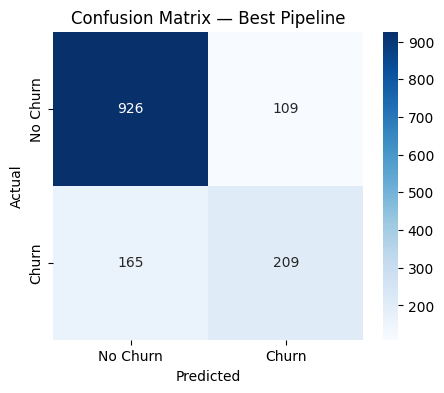

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Best Pipeline")
plt.show()


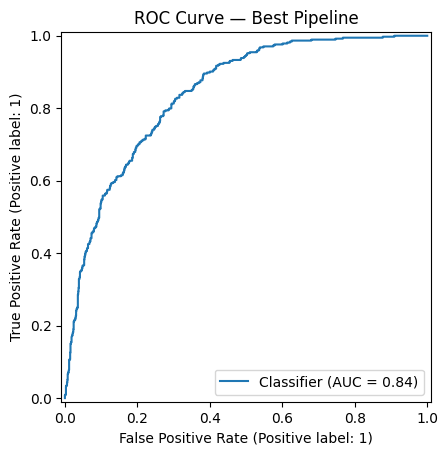

In [14]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Best Pipeline")
plt.show()


## 10. Compare Logistic Regression vs. Random Forest Results

In [15]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df["model"] = results_df["param_classifier"].apply(lambda x: x.__class__.__name__)

summary = (
    results_df.groupby("model")["mean_test_score"]
    .agg(["mean", "max"])
    .rename(columns={"mean": "avg_roc_auc", "max": "best_roc_auc"})
    .sort_values("best_roc_auc", ascending=False)
)
summary


,avg_roc_auc,best_roc_auc
model,,
LogisticRegression,0.844747,0.845855
RandomForestClassifier,0.838225,0.845218


## 11. Export the Complete Pipeline with `joblib`

The exported `.joblib` file contains **everything**: preprocessing (imputation, scaling,
encoding) and the tuned classifier — all bundled as a single object. This is what makes
it production-ready: any future raw data with the same raw columns can be fed directly
into `pipeline.predict()` without needing to re-implement preprocessing.


In [16]:
MODEL_PATH = "churn_pipeline.joblib"
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Pipeline saved to {MODEL_PATH}")


Pipeline saved to churn_pipeline.joblib


In [17]:
# Verify: reload the pipeline from disk and confirm predictions match
loaded_pipeline = joblib.load(MODEL_PATH)

sample = X_test.iloc[:5]
original_preds = best_pipeline.predict(sample)
reloaded_preds = loaded_pipeline.predict(sample)

print("Original predictions :", original_preds)
print("Reloaded predictions :", reloaded_preds)
assert (original_preds == reloaded_preds).all(), "Mismatch after reload!"
print("\n✅ Reloaded pipeline produces identical predictions — safe for production use.")


Original predictions : [0 1 0 0 0]
Reloaded predictions : [0 1 0 0 0]

✅ Reloaded pipeline produces identical predictions — safe for production use.


In [18]:
# (Colab) Download the saved pipeline to your local machine
from google.colab import files
files.download(MODEL_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Example: Using the Saved Pipeline for Inference on New Data

This simulates how the pipeline would be used in a production service — e.g., inside a
Flask/FastAPI endpoint, a Streamlit app, or a batch scoring job. You only need the raw
feature columns; the pipeline itself handles all preprocessing.


In [19]:
# Grab one raw, unprocessed customer record (as it would arrive from a database/API)
new_customer = X_test.iloc[[0]]
print("Raw input features:")
display(new_customer)

pred = loaded_pipeline.predict(new_customer)[0]
proba = loaded_pipeline.predict_proba(new_customer)[0][1]

print(f"\nPredicted churn: {'Yes' if pred == 1 else 'No'}")
print(f"Churn probability: {proba:.2%}")


Raw input features:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2



Predicted churn: No
Churn probability: 4.82%
